In [40]:
import sys
from pathlib import Path

# Walk up from the notebook's location until we find the directory
# containing the `eccopy` package folder, then add it to sys.path.
here = Path.cwd()
for candidate in [here, *here.parents]:
    if (candidate / "eccopy").is_dir():
        sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find the eccopy package folder above the current directory")

print("Using eccopy from:", candidate)

Using eccopy from: /home/icornejo/EccoPy/eccopy_pkg


# EccoPy-2D-V Workflow Template

Minimal template: load a real ECCO-V (MATLAB) case, clean it, run EccoPy,
load MATLAB's real output. Comparison / metrics / plotting are left to you.

**Case folder** should contain `ECCO_IN_*.npz` (DBZ, R_km, Z_km, optionally
TEMP) and `ECCO_OUT*.npz` (ECHOTYPE, CONVECTIVITY) — plus the original
`.sh`/`.m` driver scripts, useful for confirming exact parameter values.

Two things worth knowing before you start (see README "Validation status"
for full details):
1. Real MATLAB/LROSE data commonly uses a literal `-9999.0` fill value,
   not NaN — clean it yourself (Step 2) or EccoPy will treat it as real
   (very low) reflectivity.
2. `height`/`topo` are accepted by EccoPy in **km**, not metres.

In [41]:
import numpy as np
import glob
import warnings
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from eccopy import eccopy2d_v
from eccopy.params import WindowSpec, TextureParams, ClassificationParams, VerticalParams

In [42]:
# Define color ranges
colors1 = [(0, 0, 1), (0, 0.5, 1), (0.5, 0.75, 1)]  # Dark blue to light blue
colors2 = [(0, 0.5, 0.5), (0, 1, 1)]                  # Dark teal to light teal
colors3 = [(1, 0.75, 0.75), (1, 0, 0)]               # Light red to dark red

# Create a colormap with defined boundaries
cmap_conv = colors.LinearSegmentedColormap.from_list("custom_cmap", 
                                           [(0, colors1[0]), (0.4, colors1[2]),
                                            (0.4, colors2[0]), (0.5, colors2[1]),
                                            (0.5, colors3[0]), (1, colors3[1])])
cmap_basic = colors.ListedColormap([colors1[0], colors2[0], colors3[1]])

## Step 1 — Locate the case files

In [43]:
CASE_DIR = "/home/icornejo/EccoPy/Test_Cases/ECCO_V_CASE_3_SPOL"   # <-- change to your case folder

in_files = glob.glob(f"{CASE_DIR}/**/*IN*.npz", recursive=True)
out_files = sorted(glob.glob(f"{CASE_DIR}/**/*OUT*.npz", recursive=True))

print("Input file(s):", in_files)
print("Output file(s):", out_files)

Input file(s): ['/home/icornejo/EccoPy/Test_Cases/ECCO_V_CASE_3_SPOL/ECCO_IN_20220526_084500.npz']
Output file(s): ['/home/icornejo/EccoPy/Test_Cases/ECCO_V_CASE_3_SPOL/ECCO_OUT_20220526_084500.npz']


In [44]:
INPUT_FILE = in_files[0]
OUTPUT_FILE = out_files[0]   # <-- change index if there are multiple TEST variants

data_in = np.load(INPUT_FILE)
data_out = np.load(OUTPUT_FILE)

print("Input fields:", data_in.files)
print("Output fields:", data_out.files)

Input fields: ['DBZ', 'LAT', 'LON', 'R_km', 'Z_km', 'TEMP']
Output fields: ['CONVECTIVITY', 'ECHOTYPE']


## Step 2 — Load and clean the data

Clean literal `-9999.0` fill values to NaN before calling EccoPy.

In [45]:
dbz = data_in['DBZ'].astype(float)
dbz[dbz == -9999.0] = np.nan   # <-- clean fill values; repeat for other arrays if needed

r_km = data_in['R_km'].astype(float)
z_km = data_in['Z_km'].astype(float)

# If your case has temperature/height/topo, load + clean them here too:
# temp_c = data_in['TEMP'].astype(float).squeeze()
# temp_c[temp_c == -9999.0] = np.nan


## Step 3 — Set parameters

Check the case's `.sh` script for `RADIUS` (bare pixel radius, NOT km)
and `DBZLIM` (→ `texture_limit_high`), and the `.m` script for any other
non-default values (enlargeMixed, enlargeConv, surfAltLim, etc.).

In [46]:
RADIUS = 19         # <-- from the case's run_ecco_v_Test_*.sh
DBZLIM = 29.0
ENLARGE_MIXED = 5
ENLARGE_CONV = 5

window = WindowSpec(RADIUS)
texture_params = TextureParams(texture_limit_high=DBZLIM)
class_params = ClassificationParams(enlarge_mixed=ENLARGE_MIXED, enlarge_conv=ENLARGE_CONV)
vert_params = VerticalParams()   # adjust if your case overrides shallow/deep thresholds

In [47]:
class_params

ClassificationParams(strat_mixed=0.4, mixed_conv=0.5, enlarge_mixed=5, enlarge_conv=5, surf_alt_lim=200.0, min_convectivity_for_convective=0.5, max_convectivity_for_stratiform=0.4, min_valid_volume_for_convective=20.0, min_vert_extent_for_convective=1.0, min_ht_km_agl_for_mid=2.0, min_ht_km_agl_for_deep=4.0, use_dual_thresholds=True, secondary_convectivity=0.65, all_subclumps_min_area_frac=0.33, each_subclump_min_area_frac=0.02, each_subclump_min_area_km2=2.0, min_overlap_for_convective_clumps=1, min_conv_fraction_for_deep=0.05, min_conv_fraction_for_shallow=0.95, max_shallow_conv_fraction_for_elevated=0.05, max_deep_conv_fraction_for_elevated=0.25, min_strat_fraction_for_strat_below=0.9)

## Step 4 — Run EccoPy

Basic classification shown below. If your case has real height/temp/topo,
uncomment and adapt the extra arguments — see README re: the
earth-curvature `topo` correction several ECCO-V cases use, and the note
that `eccopy2d_v.run()` now expects `height`/`topo` in **km**.

In [48]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    result = eccopy2d_v.run(
        dbz, coords_z=z_km, coords_x=r_km,
        window=window,
        texture_params=texture_params,
        class_params=class_params,
        vert_params=vert_params,
        # height=height_km, temp=temp_c, topo=topo_km,
    )

our_echo = result.echo_type
our_conv = result.convectivity
our_texture = result.texture

print("echo_type shape:", our_echo.shape)
print("codes present:", sorted(set(our_echo[~np.isnan(our_echo)].astype(int).tolist())))

echo_type shape: (41, 601)
codes present: [1, 2, 3]


## Step 5 — MATLAB's real output

Loaded and ready for comparison.

In [49]:
lrose_echo = data_out['ECHOTYPE']
lrose_conv = data_out['CONVECTIVITY'] if 'CONVECTIVITY' in data_out.files else None

## Your analysis

`our_echo`, `our_conv`, `our_texture` vs. `lrose_echo`, `lrose_conv` —
ready to compare, score, or plot however's useful.

Note: MATLAB's ECHOTYPE may use sub-classified codes
(14/16/18/25/32/34/36/38) even if you ran EccoPy in basic mode
(1/2/3) — you may want to map one down to the other before comparing,
e.g.:

```python
lrose_basic = np.zeros_like(lrose_echo)
lrose_basic[np.isin(lrose_echo, [14,16,18])] = 1
lrose_basic[lrose_echo == 25] = 2
lrose_basic[np.isin(lrose_echo, [32,34,36,38])] = 3
```

Text(0.01, 0.95, 'ECCO - EccoPy')

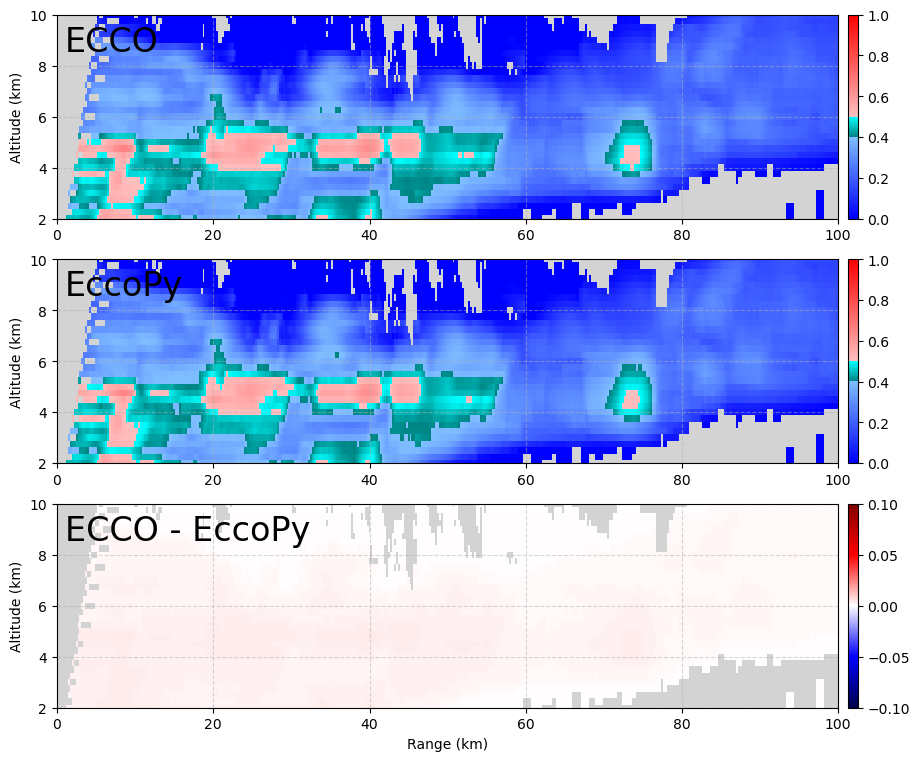

In [50]:
fig = plt.figure(figsize = (12,9))

ax1 = plt.subplot(311)
plt.pcolormesh(r_km, z_km,lrose_conv, cmap = cmap_conv, vmin = 0, vmax = 1)
plt.colorbar(pad = 0.01)
ax2 = plt.subplot(312)
plt.pcolormesh(r_km, z_km,our_conv, cmap = cmap_conv, vmin = 0, vmax = 1)
plt.colorbar(pad = 0.01)
ax3 = plt.subplot(313)
plt.pcolormesh(r_km, z_km,lrose_conv - our_conv, cmap = "seismic",vmin = -0.1, vmax = 0.1)
plt.colorbar(pad = 0.01)

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(0,100)
    ax.set_ylim(2,10)
    ax.patch.set_facecolor("lightgrey")
    ax.grid(ls = "--", alpha= 0.5)
    ax.set_ylabel("Altitude (km)")

ax3.set_xlabel("Range (km)")
ax1.text(0.01,0.95, "ECCO", ha = "left", va = "top", transform = ax1.transAxes, fontsize = 24)
ax2.text(0.01,0.95, "EccoPy", ha = "left", va = "top", transform = ax2.transAxes, fontsize = 24)
ax3.text(0.01,0.95, "ECCO - EccoPy", ha = "left", va = "top", transform = ax3.transAxes, fontsize = 24)

In [51]:
lrose_basic = np.full_like(lrose_echo, fill_value=np.nan)
lrose_basic[np.isin(lrose_echo, [14,16,18])] = 1
lrose_basic[lrose_echo == 25] = 2
lrose_basic[np.isin(lrose_echo, [32,34,36,38])] = 3

Text(0.01, 0.95, 'EccoPy')

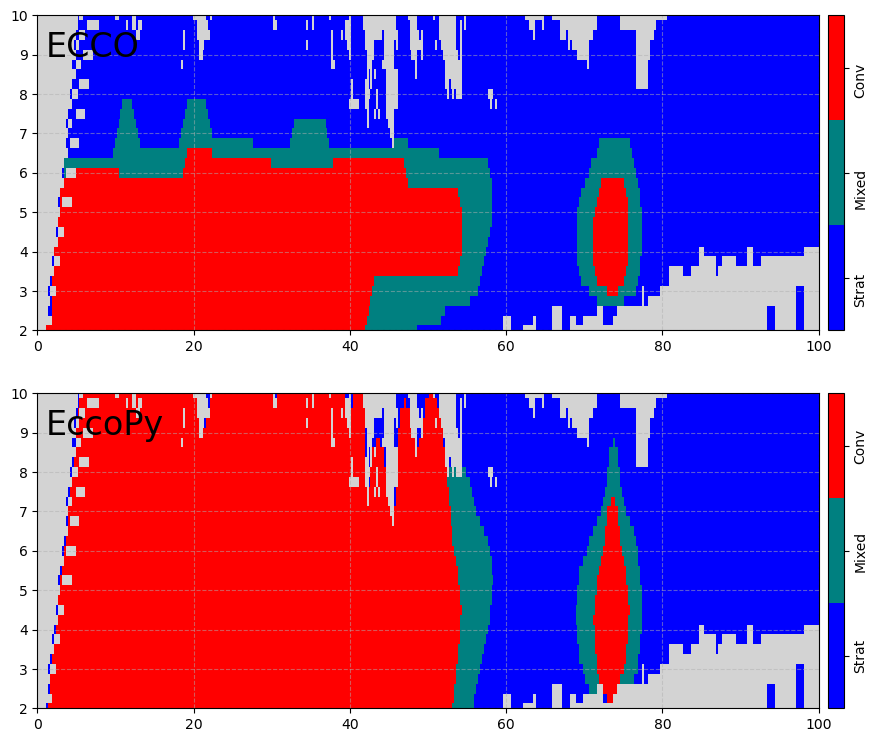

In [52]:
fig = plt.figure(figsize = (12,9))

ax1 = plt.subplot(211)
plt.pcolormesh(r_km, z_km,lrose_basic, cmap = cmap_basic, vmin = 0.5, vmax = 3.5)
cbar = plt.colorbar(pad = 0.01, ticks = [1,2,3])
cbar.ax.set_yticklabels(["Strat", "Mixed", "Conv"], rotation = 90)
ax2 = plt.subplot(212)
plt.pcolormesh(r_km, z_km,our_echo, cmap = cmap_basic, vmin = 0.5, vmax = 3.5)
cbar = plt.colorbar(pad = 0.01, ticks = [1,2,3])
cbar.ax.set_yticklabels(["Strat", "Mixed", "Conv"], rotation = 90, va = "center")

for ax in [ax1, ax2]:
    ax.set_xlim(0,100)
    ax.set_ylim(2,10)
    ax.patch.set_facecolor("lightgrey")
    ax.grid(ls = "--", alpha= 0.5)

ax1.text(0.01,0.95, "ECCO", ha = "left", va = "top", transform = ax1.transAxes, fontsize = 24)
ax2.text(0.01,0.95, "EccoPy", ha = "left", va = "top", transform = ax2.transAxes, fontsize = 24)